In [1]:
!pip install albumentations
!pip install selectivesearch
!pip uninstall opencv-contrib-python opencv-python
!pip install opencv-contrib-python
!pip install opencv-contrib-python --upgrade
from IPython.display import clear_output
clear_output(wait=True)

  Preparing metadata (setup.py) ... done
  Created wheel for selectivesearch: filename=selectivesearch-0.4-py3-none-any.whl size=4335 sha256=9ec343efceba58b8ed1dc4a6c39e1c131896e5f7602c87b316fa5b075a9f8d90
  Stored in directory: /root/.cache/pip/wheels/0e/49/95/01447a4e0f48a135ac91fbdb1dd2a1c0523e40e29957b383a3
Successfully built selectivesearch
Found existing installation: opencv-contrib-python 4.10.0.84
Uninstalling opencv-contrib-python-4.10.0.84:
  Would remove:
    /usr/local/lib/python3.10/dist-packages/cv2/*
    /usr/local/lib/python3.10/dist-packages/opencv_contrib_python-4.10.0.84.dist-info/*
    /usr/local/lib/python3.10/dist-packages/opencv_contrib_python.libs/libQt5Core-e6d3f451.so.5.15.13
    /usr/local/lib/python3.10/dist-packages/opencv_contrib_python.libs/libQt5Gui-5dea4132.so.5.15.13
    /usr/local/lib/python3.10/dist-packages/opencv_contrib_python.libs/libQt5Test-d435aae7.so.5.15.13
    /usr/local/lib/python3.10/dist-packages/opencv_contrib_python.libs/libQt5Widgets-e

In [2]:
!unzip '/content/Potholes.zip' -d '/content/'
# !unzip '/content/test_proposals.zip' -d '/content/'

Archive:  /content/Potholes.zip
   creating: /content/Potholes/
  inflating: /content/__MACOSX/._Potholes  
  inflating: /content/Potholes/.DS_Store  
  inflating: /content/__MACOSX/Potholes/._.DS_Store  
  inflating: /content/Potholes/splits.json  
  inflating: /content/__MACOSX/Potholes/._splits.json  
   creating: /content/Potholes/annotated-images/
  inflating: /content/__MACOSX/Potholes/._annotated-images  
  inflating: /content/Potholes/README.md  
  inflating: /content/__MACOSX/Potholes/._README.md  
  inflating: /content/Potholes/annotated-images/img-238.jpg  
  inflating: /content/__MACOSX/Potholes/annotated-images/._img-238.jpg  
  inflating: /content/Potholes/annotated-images/img-589.xml  
  inflating: /content/__MACOSX/Potholes/annotated-images/._img-589.xml  
  inflating: /content/Potholes/annotated-images/img-210.jpg  
  inflating: /content/__MACOSX/Potholes/annotated-images/._img-210.jpg  
  inflating: /content/Potholes/annotated-images/img-576.jpg  
  inflating: /conten

In [3]:
import albumentations as A
import os
import xml.etree.ElementTree as ET
import numpy as np
import cv2
import matplotlib.pyplot as plt
import glob
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import sys
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from PIL import Image, ImageDraw
from tqdm import tqdm
import selectivesearch
import pickle
import random

current_dir = os.getcwd()
print(current_dir)
sys.path.append(current_dir)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.21 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


/content


In [4]:
class ProposalGenerator:
    def __init__(self):
        pass

    def selective_search_fast(self, image):
        # Convert BGR to RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Compute selective search proposals
        ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
        ss.setBaseImage(image_rgb)
        ss.switchToSelectiveSearchFast()  # Use fast mode

        # Get proposals
        boxes = ss.process()

        # Convert to [x1, y1, x2, y2] format
        proposals = []
        for x, y, w, h in boxes:
            proposals.append([x, y, x+w, y+h])

        return proposals[:3000]

    def edge_boxes(self, image, max_boxes=3000, min_score=0.01):

        # Convert to RGB if necessary
        if len(image.shape) == 3 and image.shape[2] == 3:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            image_rgb = image

        # Create edge boxes detector
        edge_boxes = cv2.ximgproc.createEdgeBoxes()
        edge_boxes.setMaxBoxes(max_boxes)
        edge_boxes.setMinScore(min_score)

        # Detect edges using Canny
        edges = cv2.Canny(image_rgb, 50, 150)
        edges = edges.astype(np.float32)  # Convert edge map to CV_32F
        orientation_map = np.zeros_like(edges, dtype=np.float32)  # Placeholder orientation map

        # Get bounding boxes
        boxes = edge_boxes.getBoundingBoxes(edges, orientation_map)[0]

        #Convert to [x1, y1, x2, y2] format and scale back
        proposals = []
        for box in boxes:
            x, y, w, h = box
            x = int(x)
            y = int(y)
            w = int(w)
            h = int(h)
            proposals.append([x, y, x+w, y+h])

        return proposals[:3000]

In [5]:
import json

splits = json.load(open('/content/Potholes/splits.json'))

train_files = splits['train']
test_files = splits['test']

In [ ]:
!rm -rf test_proposals/

In [6]:
data_dir = '/content/Potholes/annotated-images'

class ImageProcessor:
    def __init__(self, files, proposal_generator, transform = None, size = (256, 256)):
        self.files = files
        self.proposal_generator = proposal_generator
        self.transform = transform
        self.size = size


    def generate_proposals(self, image, gt_boxes):
        proposals = self.proposal_generator(image)
        proposals = self.assign_labels(proposals, gt_boxes)

        return proposals

    def resize_gt_boxes(self, gt_boxes, scale):
        x_scale, y_scale = scale
        gt_boxes = [(x1 * x_scale, y1 * y_scale, x2 * x_scale, y2 * y_scale, c) for x1, y1, x2, y2, c in gt_boxes]
        return gt_boxes

    def assign_labels(self, proposals, gt_boxes, positive_iou_threshold=0.5, negative_iou_threshold=0.1):
      new_proposals = []
      for proposal in proposals:
          max_iou = 0.0
          assigned_label = 0  # Background class
          for gt_box in gt_boxes:
              iou = self.calculate_iou(proposal, gt_box)
              if iou > max_iou:
                  max_iou = iou
                  if iou >= positive_iou_threshold:
                      assigned_label = 1  # Object class label (assuming single class)
          if max_iou >= positive_iou_threshold or max_iou <= negative_iou_threshold:
              new_proposals.append([proposal[0], proposal[1], proposal[2], proposal[3], assigned_label])
          else:
              continue
              # Ignored sample
      return new_proposals

    def calculate_iou(self, box1, box2):
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])

        intersection = max(0, x2 - x1) * max(0, y2 - y1)
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

        union = area1 + area2 - intersection
        return intersection / union if union > 0 else 0

    def read_label_content(self, label_path):
        tree = ET.parse(label_path)
        root = tree.getroot()

        valid_boxes = []
        filename = root.find('filename').text
        for boxes in root.iter('object'):
            label = boxes.find("name").text
            ymin = int(boxes.find("bndbox/ymin").text)
            xmin = int(boxes.find("bndbox/xmin").text)
            ymax = int(boxes.find("bndbox/ymax").text)
            xmax = int(boxes.find("bndbox/xmax").text)

            # Check if the bounding box is valid
            # img-415 has a bug in the xml file
            # xmin = xmax.......
            # Potholes/annotated-images/img-415.xml: [xmin=273, ymin=164, xmax=273, ymax=165]
            if xmin >= xmax:
                # Optionally, log the invalid bounding box
                print(f"Invalid bbox in {label_path}: [xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}]")
                # continue  # Skip invalid bounding boxes
                xmin = xmax - 1
            if ymin >= ymax:
                # Optionally, log the invalid bounding box
                print(f"Invalid bbox in {label_path}: [xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}]")
                # continue  # Skip invalid bounding boxes
                ymin = ymax - 1

            valid_boxes.append([xmin, ymin, xmax, ymax, 1 if label == 'pothole' else 0])

        return valid_boxes, filename

    def process_image(self, idx):
        filename = os.path.splitext(self.files[idx])[0]
        image_path = os.path.join(data_dir, f'{filename}.jpg')
        label_path = os.path.join(data_dir, f'{filename}.xml')

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        gt_boxes, _ = self.read_label_content(label_path)
        if self.transform:
            transformed = self.transform(image=image, bboxes=gt_boxes)
            image = transformed['image']
            gt_boxes = transformed['bboxes']
        else:
            scale = (self.size[1] / image.shape[1], self.size[0] / image.shape[0])
            image = cv2.resize(image, self.size)
            gt_boxes = self.resize_gt_boxes(gt_boxes, scale)
        proposals = self.generate_proposals(image, gt_boxes)

        return {
            'filename': filename,
            'image': image,
            'image_path': image_path,
            'gt_boxes': gt_boxes,
            'proposals': proposals,
        }

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        return self.process_image(idx)

def precompute_proposals_and_labels(image_processor, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    for image_data in tqdm(image_processor):
        filename = image_data['filename']
        proposals = image_data['proposals']
        pos = [p for p in proposals if p[4] == 1]
        if len(pos) == 0:
            print(f'{filename} no positive proposal, ignore it')
            continue
        with open(os.path.join(output_dir, f'samples_{filename}.pkl'), 'wb') as f:
            pickle.dump(image_data, f)

size = 256
transform = A.Compose([
        A.Resize(size, size),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.RGBShift(r_shift_limit=30, g_shift_limit=30, b_shift_limit=30, p=0.3),
    ],
    bbox_params=A.BboxParams(format='pascal_voc'),
)

train_processor = ImageProcessor(train_files, ProposalGenerator().selective_search_fast, transform=transform)
precompute_proposals_and_labels(train_processor, '/content/test_proposals')
test_processor = ImageProcessor(test_files, ProposalGenerator().selective_search_fast)
precompute_proposals_and_labels(test_processor, '/content/test_proposals')

  6%|▌         | 33/532 [00:14<03:27,  2.40it/s]

img-261 no positive proposal, ignore it


 14%|█▍        | 76/532 [00:33<03:26,  2.21it/s]

img-560 no positive proposal, ignore it


 16%|█▌        | 84/532 [00:37<03:19,  2.24it/s]

...

 59%|█████▊    | 78/133 [00:33<00:23,  2.32it/s]

img-117 no positive proposal, ignore it


 74%|███████▍  | 99/133 [00:42<00:14,  2.28it/s]

img-25 no positive proposal, ignore it


100%|██████████| 133/133 [00:57<00:00,  2.32it/s]


In [7]:
!zip -r /content/test_proposals.zip /content/test_proposals


  adding: content/test_proposals/ (stored 0%)
  adding: content/test_proposals/samples_img-37.pkl (deflated 32%)
  adding: content/test_proposals/samples_img-599.pkl (deflated 39%)
  adding: content/test_proposals/samples_img-576.pkl (deflated 26%)
  adding: content/test_proposals/samples_img-572.pkl (deflated 33%)
  adding: content/test_proposals/samples_img-333.pkl (deflated 28%)
  adding: content/test_proposals/samples_img-282.pkl (deflated 44%)
  adding: content/test_proposals/samples_img-245.pkl (deflated 33%)
  adding: content/test_proposals/samples_img-271.pkl (deflated 31%)
  adding: content/test_proposals/samples_img-208.pkl (deflated 41%)
  adding: content/test_proposals/samples_img-18.pkl (deflated 37%)
  adding: content/test_proposals/samples_img-356.pkl (deflated 31%)
  adding: content/test_proposals/samples_img-255.pkl (deflated 52%)
  adding: content/test_proposals/samples_img-622.pkl (deflated 27%)
  adding: content/test_proposals/samples_img-475.pkl (deflated 35%)
  ad

In [13]:
import re
POSITIVE_RATE = 0.25
class ProposalDataset(torch.utils.data.Dataset):
    def __init__(self, files, samples_dir, num_samples = 30):
        self.samples = []
        self.num_samples = num_samples

        self.sample_files = []
        all_files = os.listdir(samples_dir)
        for filename in files:
            file_id = os.path.splitext(filename)[0]
            regex = re.compile(f"samples_{re.escape(file_id)}*\.pkl$")
            for filename in all_files:
                if regex.match(filename):
                    self.sample_files.append(os.path.join(samples_dir, filename))


    def __len__(self):
        return len(self.sample_files)

    def __getitem__(self, idx):
        sample_file = self.sample_files[idx]

        sample = pickle.load(open(sample_file, 'rb'))
        # image_path = sample['image_path']
        image = sample['image']
        # gt_boxes = np.ones((len(sample['gt_boxes']), 5))
        gt_boxes = sample['gt_boxes']

        proposals = sample['proposals']
        positives = [p for p in proposals if p[4] == 1]
        negatives = [p for p in proposals if p[4] == 0]
        num_pos_sample = int(self.num_samples * POSITIVE_RATE)
        sampled_positives = random.sample(positives, min(len(positives), num_pos_sample))
        actual_pos_count = len(sampled_positives)
        if actual_pos_count < num_pos_sample:
            total_recalculated = int((self.num_samples - actual_pos_count) / (1 - POSITIVE_RATE))
            num_neg_sample = total_recalculated - actual_pos_count
        else:
            num_neg_sample = self.num_samples - num_pos_sample
        sampled_negatives = random.sample(negatives, min(len(negatives), num_neg_sample))
        sampled_proposals = sampled_positives + sampled_negatives
        random.shuffle(sampled_proposals)

        image = torch.tensor(sample['image'], dtype=torch.int)
        proposals = torch.tensor(np.array(sampled_proposals), dtype=torch.float)
        gt_boxes = torch.tensor(gt_boxes, dtype=torch.float)
        # print(transformed)
        return image, gt_boxes, proposals

def custom_collate_fn(batch):
    return tuple(zip(*batch))

batch_size = 10
trainset = ProposalDataset(files=train_files, samples_dir='./test_proposals')

valid_idx = int(len(test_files) / 2)
validset = ProposalDataset(files=test_files[:valid_idx], samples_dir='./test_proposals')
testset = ProposalDataset(files=test_files[valid_idx:], samples_dir='./test_proposals')

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
valid_loader = DataLoader(validset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)


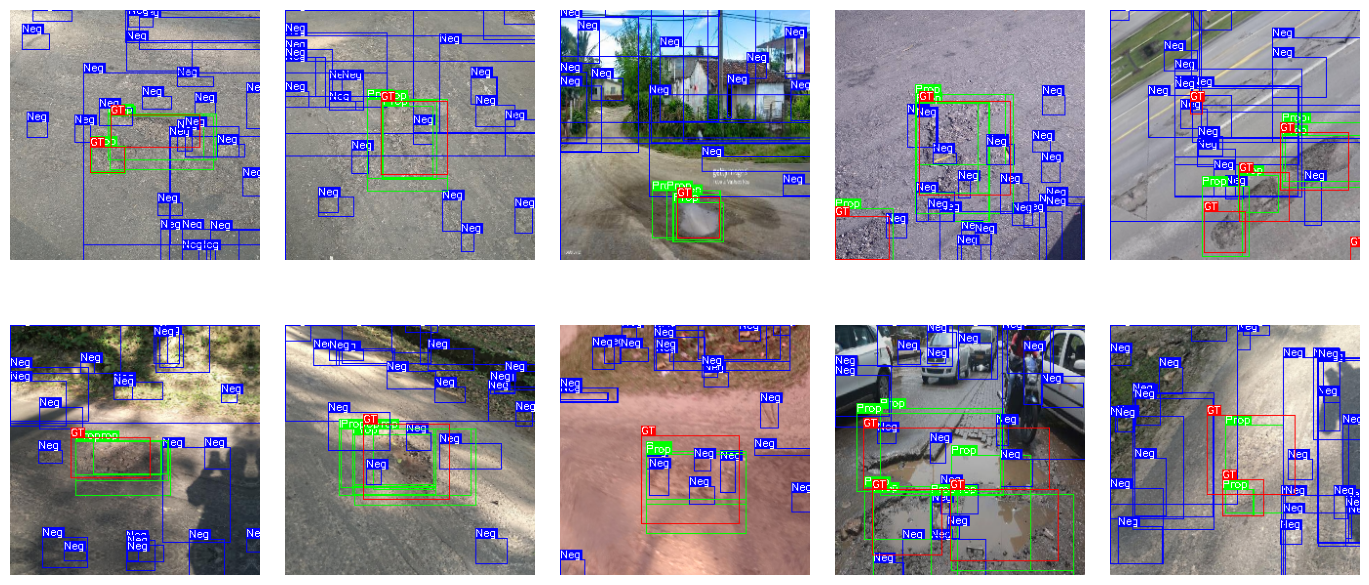

In [62]:
TEXT_COLOR = (255, 255, 255) # White
GREEN_COLOR = (0, 255, 0) # GREEN
BLUE_COLOR = (0, 0, 255) # BLUE
RED_COLOR = (255, 0, 0) # RED

def visualize_bbox(img, bbox, class_name, color=RED_COLOR, thickness=2):
    """Visualizes a single bounding box on the image"""
    x_min, y_min, x_max, y_max = bbox
    x_min, x_max, y_min, y_max = int(x_min), int(x_max), int(y_min), int(y_max)
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color=color, thickness=thickness)

    ((text_width, text_height), _) = cv2.getTextSize(class_name, cv2.FONT_HERSHEY_SIMPLEX, 0.35, 1)
    cv2.rectangle(img, (x_min, y_min - int(1.3 * text_height)), (x_min + text_width, y_min), color, -1)
    cv2.putText(
        img,
        text=class_name,
        org=(x_min, y_min - int(0.3 * text_height)),
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=0.35,
        color=TEXT_COLOR,
        lineType=cv2.LINE_AA,
    )
    return img

def visualize_proposals(img, ground_truth_boxes, proposals):
    img = img.copy()
    for proposal in proposals:
        box = proposal[:4]
        class_name = 'Prop' if proposal[4] == 1 else 'Neg'
        img = visualize_bbox(img, box, class_name, color=GREEN_COLOR if proposal[4] == 1 else BLUE_COLOR, thickness=1)
    for gt_box in ground_truth_boxes:
        img = visualize_bbox(img, gt_box[:4], 'GT', thickness=1)
    return img

images, gt_boxes, proposals = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i in range(10):
    img = visualize_proposals(images[i].numpy(), gt_boxes[i].numpy(), proposals[i].numpy())
    axes[i].imshow(img)
    axes[i].axis('off')

plt.subplots_adjust(
    left=0.05,   # Adjust the left margin
    right=0.95,  # Adjust the right margin
    top=0.95,    # Adjust the top margin
    bottom=0.05, # Adjust the bottom margin
    wspace=0.1,  # Adjust the width space between subplots
    hspace=0.001   # Adjust the height space between subplots
)
plt.show()

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import torchvision.ops as ops

print(device)
class VGG16Fast(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # remove last 2 layers
        # use resnet as our backbone
        resnet = vgg16 = models.vgg16(pretrained=True)
        modules = vgg16.features
        self.backbone = nn.Sequential(*modules)
        # 13 convolutional layers and 5 max-pooling layers. stride is 2^5
        self.roi_pool = ops.RoIAlign(output_size=(7, 7), spatial_scale=1/32, sampling_ratio = 2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, num_classes)
        )

    def forward(self, images, proposals):
        # proposals: List of Tensors, each of shape [num_proposals_i, 5] (x1, y1, x2, y2, class)
        # Permute the dimensions of the input image tensor
        #  from [batch_size, H, W, C] to [batch_size, C, H, W]
        images = images.permute(0, 3, 1, 2)
        batch_size = images.size(0)
        device = images.device

        # Compute feature maps
        feature_maps = self.backbone(images)
        # feature_maps shape: [batch_size, 512, H', W']

        # Prepare proposals for RoI pooling
        roi_pooling_boxes = []
        labels = []
        for i in range(batch_size):
            boxes = proposals[i][:, :4]  # Extract coordinates
            labels.append(proposals[i][:, 4].long().to(device))  # Extract labels
            # Add batch index
            indices = torch.full((boxes.shape[0], 1), i, dtype=boxes.dtype, device=device)
            roi_boxes = torch.cat([indices, boxes], dim=1)  # Shape: [num_proposals_i, 5]
            roi_pooling_boxes.append(roi_boxes)
        roi_pooling_boxes = torch.cat(roi_pooling_boxes, dim=0)  # Shape: [total_num_proposals, 5]

        pooled_features = self.roi_pool(feature_maps, roi_pooling_boxes)
        # pooled_features shape: [total_num_proposals, 512, 7, 7]

        logits = self.classifier(pooled_features)
        # logits shape: [total_num_proposals, num_classes]

        labels = torch.cat(labels, dim=0)

        return logits, labels


cuda


In [11]:
def train(model, train_loader, valid_loader, criterion, optimizer, num_epochs=20):
    # Lists to store loss and accuracy
    train_losses = []
    val_accuracies = []

    best_accuracy = 0.0  # For saving the best model

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total_samples = 0

        for images, gt_boxes_list, proposals_list in train_loader:
            images = torch.stack(images).type(torch.float32).to(device) / 255.0   # [batch_size, 3, H, W]

            proposals = [props.to(device) for props in proposals_list]
            logits, labels = model(images, proposals)

            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)

        epoch_loss = running_loss / total_samples
        train_losses.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, gt_boxes_list, proposals_list in valid_loader:
                images = torch.stack(images).type(torch.float32).to(device) / 255.0
                proposals = [props.to(device) for props in proposals_list]

                logits, labels = model(images, proposals)
                _, preds = torch.max(logits, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        accuracy = 100 * correct / total
        val_accuracies.append(accuracy)
        print(f"Validation Accuracy: {accuracy:.2f}%")

        # # Save the model if validation accuracy improves
        # if accuracy > best_accuracy:
        #     best_accuracy = accuracy
        #     torch.save(model.state_dict(), 'best_model.pth')
        #     print("Model saved!")

        model.train()

    # Plotting the loss and accuracy
    epochs = range(1, num_epochs + 1)

    plt.figure(figsize=(12, 5))

    # Plot training loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'bo-', label='Training Loss')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, 'ro-', label='Validation Accuracy')
    plt.title('Validation Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/30], Loss: 0.4304
Validation Accuracy: 82.23%
Epoch [2/30], Loss: 0.3175
Validation Accuracy: 87.43%
Epoch [3/30], Loss: 0.2261
Validation Accuracy: 92.41%
Epoch [4/30], Loss: 0.1823
Validation Accuracy: 94.95%
Epoch [5/30], Loss: 0.1521
Validation Accuracy: 94.60%
Epoch [6/30], Loss: 0.1273
Validation Accuracy: 95.99%
Epoch [7/30], Loss: 0.1051
Validation Accuracy: 94.95%
Epoch [8/30], Loss: 0.0910
Validation Accuracy: 96.14%
Epoch [9/30], Loss: 0.0812
Validation Accuracy: 96.96%
Epoch [10/30], Loss: 0.0718
Validation Accuracy: 97.31%
Epoch [11/30], Loss: 0.0621
Validation Accuracy: 97.26%
Epoch [12/30], Loss: 0.0602
Validation Accuracy: 97.39%
Epoch [13/30], Loss: 0.0506
Validation Accuracy: 96.64%
Epoch [14/30], Loss: 0.0481
Validation Accuracy: 97.36%
Epoch [15/30], Loss: 0.0416
Validation Accuracy: 96.81%
Epoch [16/30], Loss: 0.0411
Validation Accuracy: 97.31%
Epoch [17/30], Loss: 0.0355
Validation Accuracy: 97.26%
Epoch [18/30], Loss: 0.0352
Validation Accuracy: 97.24%
E

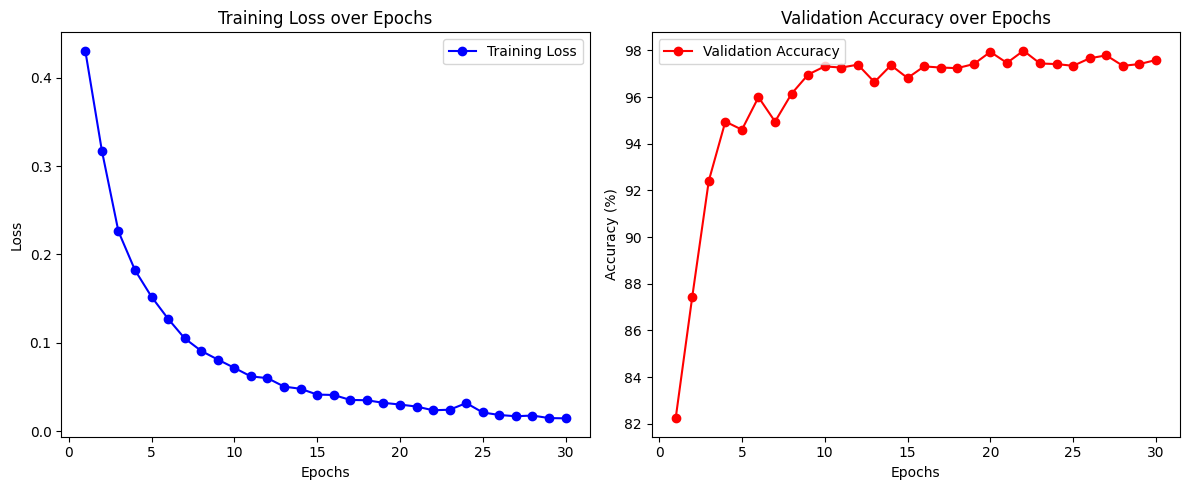

In [14]:
criterion = nn.CrossEntropyLoss()
vgg_fast = VGG16Fast().to(device)
optimizer = optim.SGD(vgg_fast.parameters(), lr=0.001, momentum=0.9)
train(vgg_fast, train_loader, valid_loader, criterion, optimizer, num_epochs=30)

In [77]:
def visualize_proposals(img, ground_truth_boxes, proposals):
    img = img.copy()
    for i, proposal in enumerate(proposals['boxes']):
        box = proposal[:4]
        score = str(proposals['scores'][i].item())
        img = visualize_bbox(img, box, score, color=BLUE_COLOR, thickness=1)
    for gt_box in ground_truth_boxes:
        img = visualize_bbox(img, gt_box[:4], 'GT', thickness=1)
    return img

def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    val_accuracies = []
    with torch.no_grad():
      for images, gt_boxes_list, proposals_list in valid_loader:
        images = torch.stack(images).type(torch.float32).to(device) / 255.0
        proposals = [props.to(device) for props in proposals_list]

        logits, labels = model(images, proposals)
        _, preds = torch.max(logits, 1)
        scores = torch.softmax(logits, dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        box = nms_by_batch(proposals_list, scores.cpu(), preds.cpu())

        # fig, axes = plt.subplots(2, 5, figsize=(20, 10))
        # axes = axes.flatten()

        # for i in range(len(images)):
        #     img = visualize_proposals(images[i].cpu().numpy(), gt_boxes_list[i].cpu().numpy(), box[i])
        #     axes[i].imshow(img)
        #     axes[i].axis('off')

        # plt.subplots_adjust(
        #     left=0.05,   # Adjust the left margin
        #     right=0.95,  # Adjust the right margin
        #     top=0.95,    # Adjust the top margin
        #     bottom=0.05, # Adjust the bottom margin
        #     wspace=0.1,  # Adjust the width space between subplots
        #     hspace=0.001   # Adjust the height space between subplots
        # )

        # plt.show()

    accuracy = 100 * correct / total
    val_accuracies.append(accuracy)
    print(f"Validation Accuracy: {accuracy:.2f}%")


test(vgg_fast, test_loader)

# calculate nms batch to batch
def nms_by_batch(proposals_list, scores, preds, iou_threshold=0.7):
    keep_boxes = []
    start = 0
    for i, proposals in enumerate(proposals_list):
        num_proposals = proposals.shape[0]
        end = start + num_proposals

        image_proposals = proposals[:, :4]          # Shape: [num_proposals, 4]
        image_scores = scores[start:end]            # Shape: [num_proposals, 2]
        image_preds = preds[start:end]              # Shape: [num_proposals]

        # Extract positive predictions
        positive_indices = (image_preds == 1)

        if positive_indices.sum() == 0:
            # No positive detections for this image
            keep_boxes.append({'boxes': torch.empty((0, 4)), 'scores': torch.empty((0,))})
            start = end
            continue

        pos_boxes = image_proposals[positive_indices]
        pos_scores = image_scores[positive_indices, 1]  # Probability of positive class

        # Apply NMS
        keep_indices = nms_by_class(pos_boxes, pos_scores, iou_threshold=iou_threshold)
        nms_boxes = pos_boxes[keep_indices]
        nms_scores = pos_scores[keep_indices]

        keep_boxes.append({'boxes': nms_boxes, 'scores': nms_scores})

        start = end

    return keep_boxes

def nms_by_class(boxes, scores, iou_threshold=0.7):
    sorted_indices = torch.argsort(scores, descending=True)
    sorted_boxes = boxes[sorted_indices]
    sorted_scores = scores[sorted_indices]

    keep_boxes = []
    keep_scores = []

    while len(sorted_boxes) > 0:
      current_box = sorted_boxes[0]
      current_score = sorted_scores[0]

      sorted_boxes = sorted_boxes[1:]
      sorted_scores = sorted_scores[1:]

      keep_boxes.append(current_box)
      keep_scores.append(current_score)
      print(current_box)
      print(sorted_boxes.shape())
      if len(sorted_boxes) == 1:
        break







AttributeError: 'Tensor' object has no attribute 'pop'